In [1]:
from pathlib import Path
current_dir = Path().resolve()
from microlive.imports import *
from microlive import microscopy as mi
main_dir = Path().resolve().parent
import tasep_models as tm
from tasep_models import *
from Bio import pairwise2
from Bio.pairwise2 import format_alignment  
import multiprocessing as mp
import os
mp.set_start_method('spawn', force=True)
os.environ['PYTHONWARNINGS'] = 'ignore::UserWarning:multiprocessing.resource_tracker'

In [2]:
# reload module microlive
import importlib
importlib.reload(mi)

In [3]:
# Load the sequences.
HA_TAG = 'YPYDVPDYA'
GFP_TAG = 'LEFVTAA'  
MCHERRY_TAG = 'QYERAEG'
XBP1 = 'KDPVPYQPPFLCQWGRHQPAWKPLMN'
TAG_list = [HA_TAG, GFP_TAG, MCHERRY_TAG]


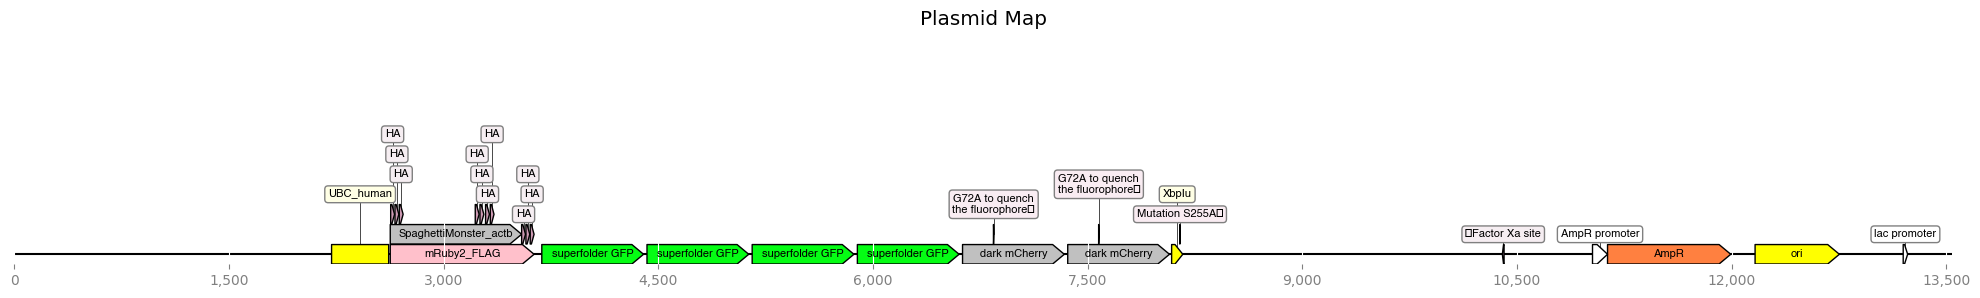

Plasmid name: pRS038 (pUB-RBsmHA-4xsfGFPq-2xmChq-Xbp1(S255A)-24xMS2)


In [4]:
# Load sequences.
gene_sequence_pRS038= current_dir.parents[1].joinpath('data', 'gene_sequences', 'pRS038 (pUB-RBsmHA-4xsfGFPq-2xmChq-Xbp1(S255A)-24xMS2).dna')
gene_sequence_pRS048 = current_dir.parents[1].joinpath('data', 'gene_sequences', 'pRS048 (pUB-RBsmHA-XBP1(S255A)-4xsfGFPq-2xmChq-24xMS2) 1.dna')

selected_gene_sequence = gene_sequence_pRS038
data_sequence = read_gene_sequence(selected_gene_sequence, TAG_list, PAUSE_SEQUENCE=XBP1)

plasmid_name = selected_gene_sequence.stem
print(f"Plasmid name: {plasmid_name}")


In [5]:
# # Initial conditions
ki = 0.06  # Initiation rate
global_elongation_rate = 5  # Elongation rates for positions 1 to N-1
#pause_elongation_rate = global_elongation_rate/40

pause_duration_s = 40 # seconds. This is 40 seconds as reported by Yan et al 2016.
pause_elongation_rate = 1/ pause_duration_s  # codons / s

number_repetitions = 200
burnin_time = 2500
t_max = 360*10 #timePerturbationApplication + 25*60  # Maximum time
step_size_in_sec = 5 # 5
time_array = np.arange(0, t_max, step_size_in_sec)
number_tested_parameters = 5
MAD_THRESHOLD_FACTOR = 4
folding_delay = 10  # seconds
efficiency_list = [1, 1]  # binding efficiency for the two probes
ke = calculate_codon_elongation_rates (data_sequence['rna'], global_elongation_rate=global_elongation_rate)

intensity_vector_first_signal_ode,intensity_vector_second_signal_ode = simulate_TASEP_ODE(ki, ke, 
                                                                                          gene_length = data_sequence['gene_length'], 
                                                                                          t_max = t_max,
                                                                                          first_probe_position_vector = data_sequence['probe_data']['tag_0']['position_cumulative_vector'],
                                                                                          second_probe_position_vector = data_sequence['probe_data']['tag_1']['position_cumulative_vector'],
                                                                                          burnin_time = burnin_time,
                                                                                          pause_location=data_sequence['pause_indexes'],
                                                                                          pause_elongation_rate = pause_elongation_rate,
                                                                                          time_interval_in_seconds = step_size_in_sec)

constant_elongation_rate = None # this is a signal to the SSA to use the elongation rates considering sequence variability.
list_ribosome_trajectories,list_occupancy_output, matrix_intensity_first_signal_RT, matrix_intensity_second_signal_RT = simulate_TASEP_SSA(ki, ke, 
                                                                                                                        gene_length = data_sequence['gene_length'],
                                                                                                                        t_max = t_max,
                                                                                                                        time_interval_in_seconds = step_size_in_sec,
                                                                                                                        number_repetitions = number_repetitions, 
                                                                                                                        first_probe_position_vector = data_sequence['probe_data']['tag_0']['position_cumulative_vector'],
                                                                                                                        second_probe_position_vector = data_sequence['probe_data']['tag_1']['position_cumulative_vector'],
                                                                                                                        burnin_time = burnin_time,
                                                                                                                        folding_delay=folding_delay,
                                                                                                                        constant_elongation_rate = constant_elongation_rate,
                                                                                                                        efficiency_list = efficiency_list,
                                                                                                                        pause_location=data_sequence['pause_indexes'],
                                                                                                                        pause_elongation_rate = pause_elongation_rate,
                                                                                                                        fast_output = False)


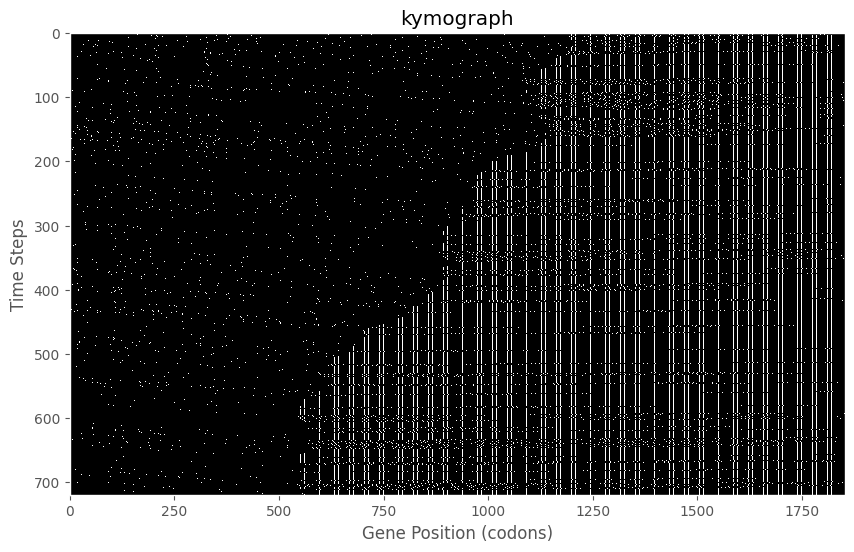

In [6]:
plot_kymograph(list_occupancy_output, selected_trajectory = 0, figsize=(10,6), ylabel='Time Steps', title='kymograph',)

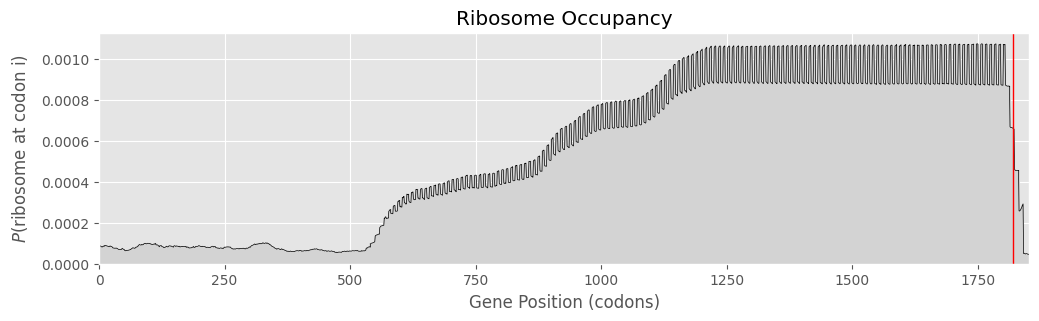

In [7]:
plot_ribosome_density(list_occupancy_output, data_sequence, selected_trajectory = 0, figsize=(12,3), smooth_window = 40,)

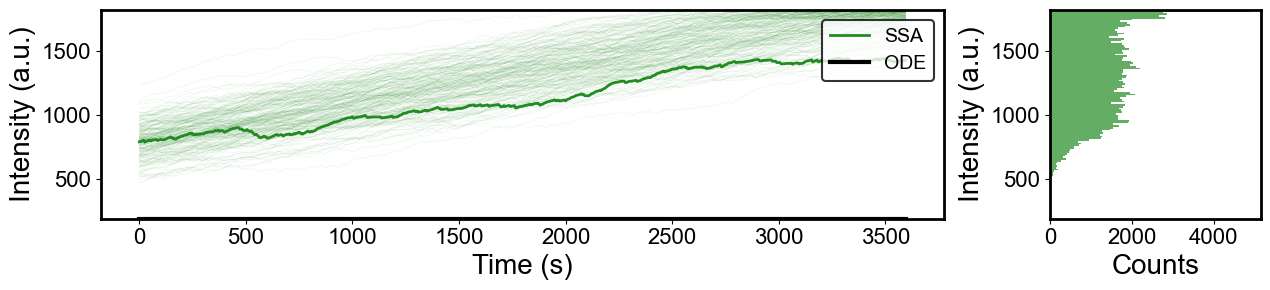

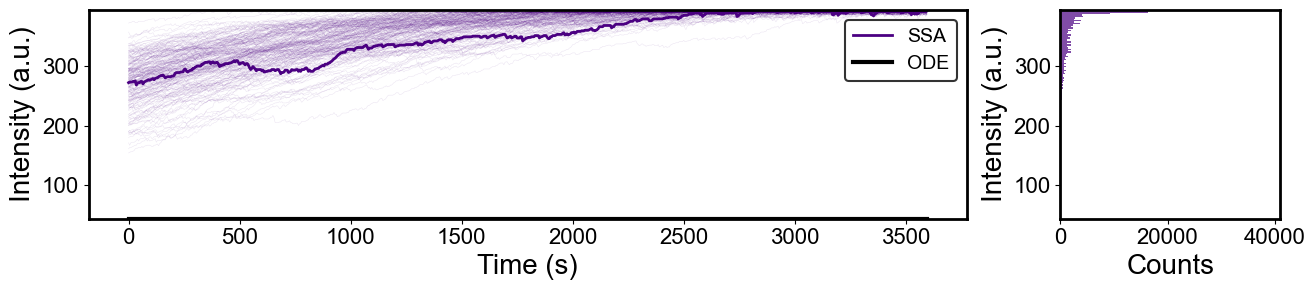

In [8]:
plot_trajectories(matrix_intensity_first_signal_RT, intensity_vector_first_signal_ode, time_array, number_repetitions,plot_color='forestgreen')
plot_trajectories(matrix_intensity_second_signal_RT, intensity_vector_second_signal_ode, time_array, number_repetitions,plot_color='indigo')

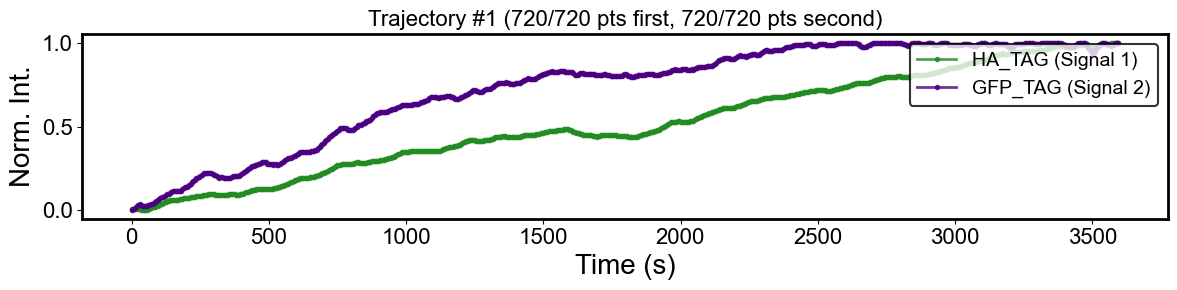

In [9]:
plot_dual_signal_trajectories(matrix_intensity_first_signal_RT, matrix_intensity_second_signal_RT, 
                              time_array, trajectory_index=1, 
                              colors=['forestgreen', 'indigo'], 
                              labels=['HA_TAG (Signal 1)', 'GFP_TAG (Signal 2)'], 
                              smooth_window=5,
                              normalize=True)

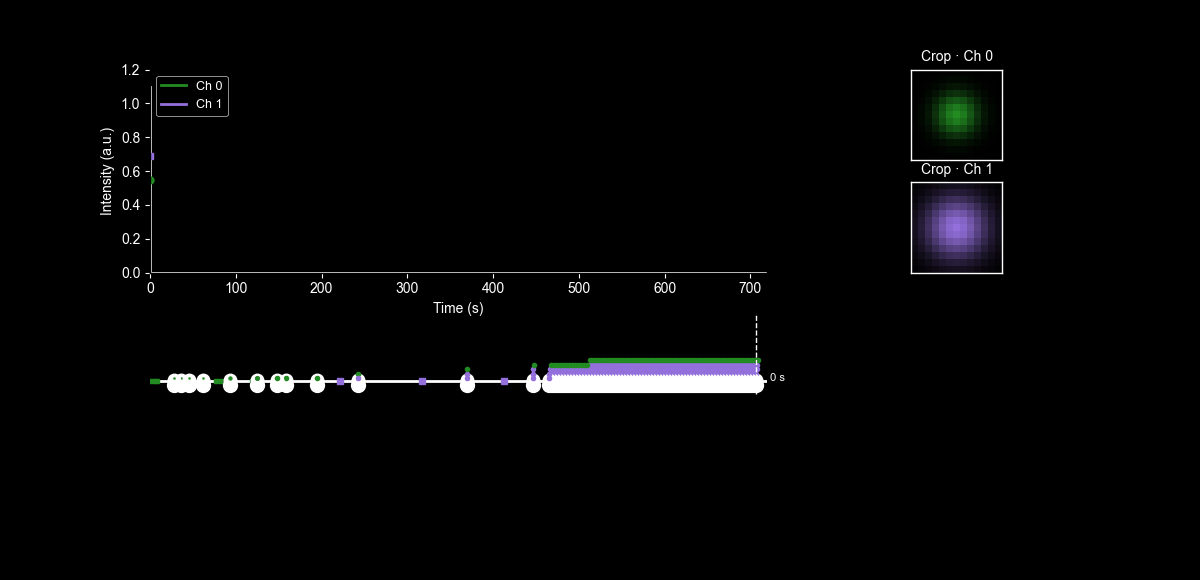

In [10]:
# plot the animation of the ribosome movement
str_ki = str(ki).replace('.','_')
str_k = str(global_elongation_rate).replace('.','_')
fileNameGif = 'simulation_'+plasmid_name+'_ke_'+str_k+'_ki_'+str_ki 
selected_index_trajectory = 0  # Change this index to visualize different trajectories
ribosome_trajectories = list_ribosome_trajectories[selected_index_trajectory]
intensity_vector_first_signal = matrix_intensity_first_signal_RT[selected_index_trajectory]
intensity_vector_second_signal = matrix_intensity_second_signal_RT[selected_index_trajectory]
tag_positions_first_probe_vector = data_sequence['probe_data']['tag_0']['positions']
tag_positions_second_probe_vector = data_sequence['probe_data']['tag_1']['positions']
color = 'forestgreen'
second_color = 'mediumpurple'
plot_RibosomeMovement_and_Microscope(ribosome_trajectories, intensity_vector_first_signal, tag_positions_first_probe_vector, SecondIntensityVector=intensity_vector_second_signal, 
                                     second_probePositions=tag_positions_second_probe_vector,FrameVelocity=10,fileNameGif=fileNameGif,color=color,second_color=second_color,pause_location=data_sequence['pause_indexes'])

In [11]:

# calculating the mean occupancy across all frames
gene_length = data_sequence['gene_length']
ribosomal_density = np.round( (gene_length/global_elongation_rate) *ki , 1)
print(f'Ribosomal density: {ribosomal_density} ribosomes per gene length ({gene_length} codons)')
ribosomal_footprint = 10
ribosomal_density_coverage = np.round( (ribosomal_density * ribosomal_footprint) / gene_length, 2)
percentage_coverage = (ribosomal_density_coverage * 100)  # percentage coverage of the gene length by ribosomes
print(f'Ribosomal density coverage: {np.round(ribosomal_density_coverage,2)} ribosomes per gene length ({gene_length} codons, {percentage_coverage:.2f}% coverage)')
len(list_occupancy_output)
occupancy_array = np.array([np.mean(np.count_nonzero(occupancy, axis=0)) for occupancy in list_occupancy_output])
print(f'Ribosomal density with simulated data: { np.round( np.mean(occupancy_array), 2)} ribosomes per gene length ({gene_length} codons)')


Ribosomal density: 22.2 ribosomes per gene length (1852 codons)
Ribosomal density coverage: 0.12 ribosomes per gene length (1852 codons, 12.00% coverage)
Ribosomal density with simulated data: 135.18 ribosomes per gene length (1852 codons)


Decorrelation threshold value: 0.015365242985335807


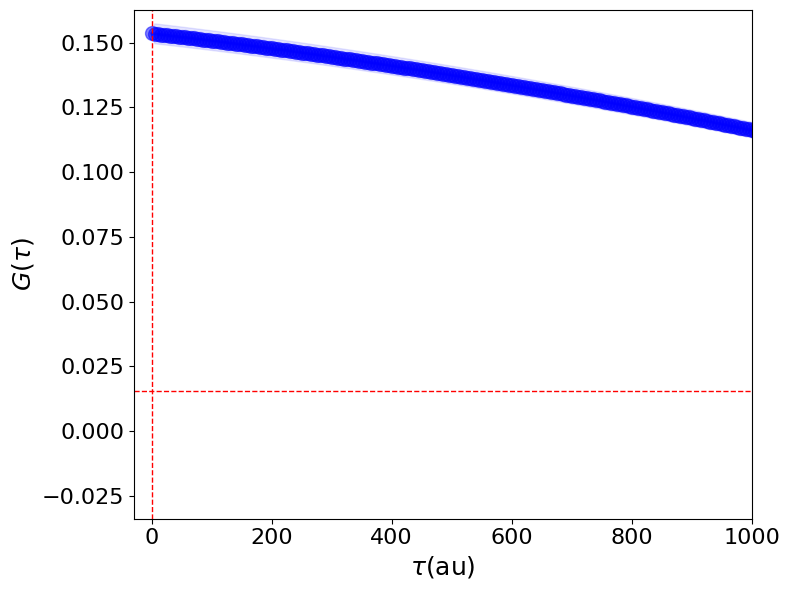

In [12]:

mean_correlation_ssa, std_correlation_ssa, lags_ssa, correlations_array, dwell_time = mi.Correlation(primary_data=matrix_intensity_first_signal_RT,   # HA first (reference)
                                                                                                    secondary_data=None, # GFP second (delayed)
                                                                                                    max_lag=None, 
                                                                                                    nan_handling='forward_fill',  #forward_fill, 'ignore'
                                                                                                    shift_data=True,
                                                                                                    return_full=False,
                                                                                                    time_interval_between_frames_in_seconds=step_size_in_sec,
                                                                                                    use_bootstrap=True,
                                                                                                    show_plot=True,
                                                                                                    start_lag=0,
                                                                                                    fit_type='linear',
                                                                                                    de_correlation_threshold=0.1,
                                                                                                    correct_baseline=True,
                                                                                                    use_linear_projection_for_lag_0=True,
                                                                                                    save_plots=False,
                                                                                                    use_global_mean= False,
                                                                                                    remove_outliers = True,
                                                                                                    MAD_THRESHOLD_FACTOR = 6,
                                                                                                    plot_individual_trajectories = False,
                                                                                                    x_axes_min_max_list_values=[-30,1000],
                                                                                                    plot_title=None).run()

maximum lag:  -10.0


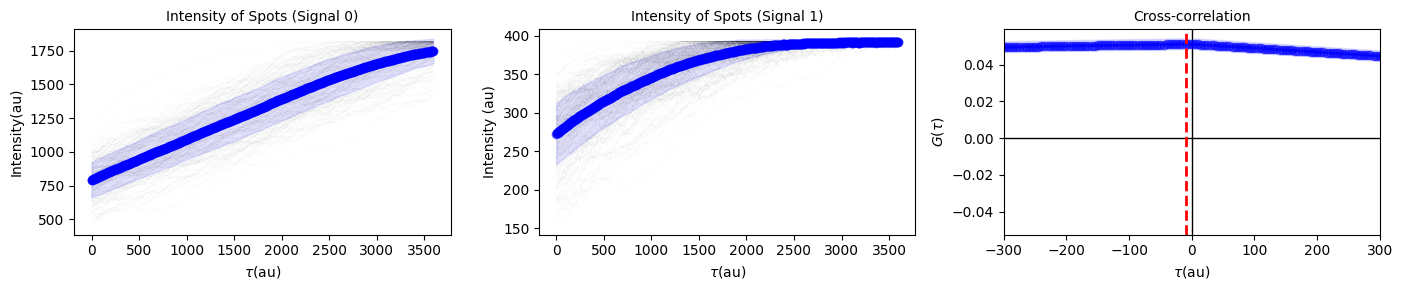

In [13]:

mean_correlation_ssa, std_correlation_ssa, lags_ssa, correlations_array, dwell_time = mi.Correlation(primary_data=matrix_intensity_first_signal_RT,   # HA first (reference)
                                                                                                    secondary_data=matrix_intensity_second_signal_RT, # GFP second (delayed)
                                                                                                    max_lag=None, 
                                                                                                    nan_handling='forward_fill',  #forward_fill, 'ignore'
                                                                                                    shift_data=True,
                                                                                                    return_full=True,
                                                                                                    time_interval_between_frames_in_seconds=step_size_in_sec,
                                                                                                    use_bootstrap=True,
                                                                                                    show_plot=True,
                                                                                                    start_lag=0,
                                                                                                    fit_type='linear',
                                                                                                    de_correlation_threshold=0.1,
                                                                                                    correct_baseline=True,
                                                                                                    use_linear_projection_for_lag_0=True,
                                                                                                    save_plots=False,
                                                                                                    use_global_mean= False,
                                                                                                    remove_outliers = True,
                                                                                                    MAD_THRESHOLD_FACTOR = 6,
                                                                                                    plot_individual_trajectories = False,
                                                                                                    x_axes_min_max_list_values=[-300,300],
                                                                                                    plot_title=None).run()

In [14]:
# Expected values based on your parameters
tag_0_positions = data_sequence['probe_data']['tag_0']['positions']  # HA_TAG
tag_1_positions = data_sequence['probe_data']['tag_1']['positions']  # GFP_TAG
print("-" * 40)
print(f"Tag 0 positions (HA_TAG): {tag_0_positions}")
print(f"Tag 1 positions (GFP_TAG): {tag_1_positions}")
print("-" * 40)

avg_distance = np.mean(tag_1_positions) - np.mean(tag_0_positions)
expected_transit_time = avg_distance / global_elongation_rate
expected_lag_frames = expected_transit_time / step_size_in_sec
print("-" * 40)
print(f"Expected distance: {avg_distance:.1f} codons")
print(f"Expected transit time: {expected_transit_time:.1f} seconds") 
print("-" * 40)

# calculate this considering the last position of tag 0 and the first position of tag 1
avg_distance_edge = np.min(tag_1_positions) - np.max(tag_0_positions)
expected_transit_time_edge = avg_distance_edge / global_elongation_rate
expected_lag_frames_edge = expected_transit_time_edge / step_size_in_sec
print("-" * 40)
print(f"Expected distance (edge to edge): {avg_distance_edge:.1f} codons")
print(f"Expected transit time (edge to edge): {expected_transit_time_edge:.1f} seconds")
print("-" * 40)

----------------------------------------
Tag 0 positions (HA_TAG): [1, 11, 21, 198, 209, 222, 233, 306, 316, 326]
Tag 1 positions (GFP_TAG): [572, 817, 1062, 1307]
----------------------------------------
----------------------------------------
Expected distance: 755.2 codons
Expected transit time: 151.0 seconds
----------------------------------------
----------------------------------------
Expected distance (edge to edge): 246.0 codons
Expected transit time (edge to edge): 49.2 seconds
----------------------------------------


In [ ]:
gene_length = data_sequence['gene_length']
tested_elongation_rates = [2, 4, 6, 8, 10]
for rate in tested_elongation_rates:
    total_transit_time = gene_length / rate
    print(f"Total transit time (full length) at {rate} codons/sec: {total_transit_time:.1f} seconds")

Total transit time (full length) at 2 codons/sec: 926.0 seconds
Total transit time (full length) at 4 codons/sec: 463.0 seconds
Total transit time (full length) at 6 codons/sec: 308.7 seconds
Total transit time (full length) at 8 codons/sec: 231.5 seconds
Total transit time (full length) at 10 codons/sec: 185.2 seconds


Exception ignored in: <function ResourceTracker.__del__ at 0x106293560>
Traceback (most recent call last):
  File "/opt/anaconda3/envs/micro/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/opt/anaconda3/envs/micro/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/opt/anaconda3/envs/micro/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10712b560>
Traceback (most recent call last):
  File "/opt/anaconda3/envs/micro/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/opt/anaconda3/envs/micro/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/opt/anaconda3/envs/micro/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function Resour